In [2]:
import importlib
import sys
sys.path.append('../code')

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

import SeaLevelContrib as slc

import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')

In [3]:
importlib.reload(slc)

<module 'SeaLevelContrib' from 'C:\\Users\\kyrab\\Github\\SLBudget\\notebooks\\../code\\SeaLevelContrib.py'>

In [4]:
data_path = '../data/GravIs/'

In [53]:
# Maak jaarlijkse dataset: 
ant = xr.open_dataset(data_path + "GRAVIS-3_COSTG_0100_AIS_GRID_TUD_0003.nc")
gre = xr.open_dataset(data_path + "GRAVIS-3_COSTG_0100_GIS_GRID_TUD_0003.nc")

# Drop dm, time_dec, and the old time coordinate: this is everything that dempends on time
ant_y = ant.drop_vars(['dm', 'time_dec', 'time'], errors='ignore')
gre_y = gre.drop_vars(['dm', 'time_dec', 'time'], errors='ignore')

# Resample dm to yearly
dm_y = ant['dm'].resample(time='1Y').mean(keep_attrs=True)
dm_y_g = gre['dm'].resample(time='1Y').mean(keep_attrs=True)

# Ensure correct order
dm_y = dm_y.transpose('time', 'y', 'x')
dm_y_g = dm_y_g.transpose('time', 'y', 'x')

# Assign dm back
ant_y = ant_y.assign({'dm': dm_y})
gre_y = gre_y.assign({'dm': dm_y_g})

# Assign the time coordinate from dm_y (now no conflicts)
ant_y = ant_y.assign_coords(time=dm_y['time'])
gre_y = gre_y.assign_coords(time=dm_y_g['time'])

# Compute decimal year as a NumPy array
time_dec = ant_y["time"].dt.year 
time_dec_g = gre_y["time"].dt.year 

# Add it as a new variable (not just a coordinate)
ant_y["time_dec"] = ("time", time_dec.data)
gre_y["time_dec"] = ("time", time_dec_g.data)

# Add metadata (optional but good practice)
ant_y["time_dec"].attrs = {
    "long_name": "Decimal year",
    "units": "year"
}

gre_y["time_dec"].attrs = {
    "long_name": "Decimal year",
    "units": "year"
}


display(ant_y)

C:\Users\kyrab\anaconda3\envs\p313ds\Lib\site-packages\xarray\groupers.py:530: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(
C:\Users\kyrab\anaconda3\envs\p313ds\Lib\site-packages\xarray\groupers.py:530: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


<xarray.Dataset> Size: 2MB
Dimensions:   (y: 97, x: 117, time: 23)
Coordinates:
  * x         (x) float64 936B -2.9e+06 -2.85e+06 -2.8e+06 ... 2.85e+06 2.9e+06
  * y         (y) float64 776B -2.4e+06 -2.35e+06 -2.3e+06 ... 2.35e+06 2.4e+06
  * time      (time) datetime64[ns] 184B 2002-12-31 2003-12-31 ... 2024-12-31
Data variables:
    lon       (y, x) float64 91kB ...
    lat       (y, x) float64 91kB ...
    area      (y, x) float64 91kB ...
    crs       |S1 1B ...
    dm        (time, y, x) float64 2MB nan nan nan nan nan ... nan nan nan nan
    time_dec  (time) int64 184B 2002 2003 2004 2005 2006 ... 2021 2022 2023 2024
Attributes: (12/16)
    title:                Gridded AIS Mass Changes
    institution:          TU Dresden, Chair of Geodetic Earth System Research
    authors:              Andreas Groh, Martin Horwath, Thorben Döhne
    project:              GravIS GRACE/GRACE-FO Level-3 Products
    source:               Monthly COST-G RL01 GRACE/GRACE-FO Level-2B product...
    summary:              GRACE/GRACE-FO derived time series of gridded Antar...
    ...                   ...
    product_version:      0003
    doi:                  10.5880/COST-G.GRAVIS_01_L3_ICE
    netCDF_version:       netCDF-4_classic
    conventions:          CF-1.6
    date_created:         2025-04-07
    contact:              thorben.doehne@tu-dresden.de

In [6]:
Gravis_dir = '../outputs/Gravis_Antarctica/'
Gravis_ant_ds = xr.open_dataset(f'{Gravis_dir}Gravis_Ant_new_weighted.nc')

#Optional: scale data by factor 1.2 or 1.1837950465122913
Gravis_ant_ds['AIS_Gravis'] = Gravis_ant_ds['AIS_Gravis']*1.1837950465122913
Gravis_ant_ds['Meanslr'] = Gravis_ant_ds['Meanslr']*1.1837950465122913

display(Gravis_ant_ds)
#Gravis_gre_ds = xr.open_dataset(f'{Gravis_dir}Gravis_gre.nc')
#display(Gravis_gre_ds)


<xarray.Dataset> Size: 12MB
Dimensions:     (time: 23, lat: 180, lon: 360)
Coordinates:
  * lon         (lon) float64 3kB 0.5 1.5 2.5 3.5 ... 356.5 357.5 358.5 359.5
  * lat         (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 87.5 88.5 89.5
  * time        (time) int64 184B 2002 2003 2004 2005 ... 2021 2022 2023 2024
Data variables:
    AIS_Gravis  (time, lat, lon) float64 12MB 0.0 0.0 0.0 ... 0.8624 0.86 0.8575
    Meanslr     (time) float64 184B 0.0 0.02624 0.05696 ... 0.6755 0.6681 0.7139
Attributes:
    Info:     Based on Gravis data and created using the gravity toolkit

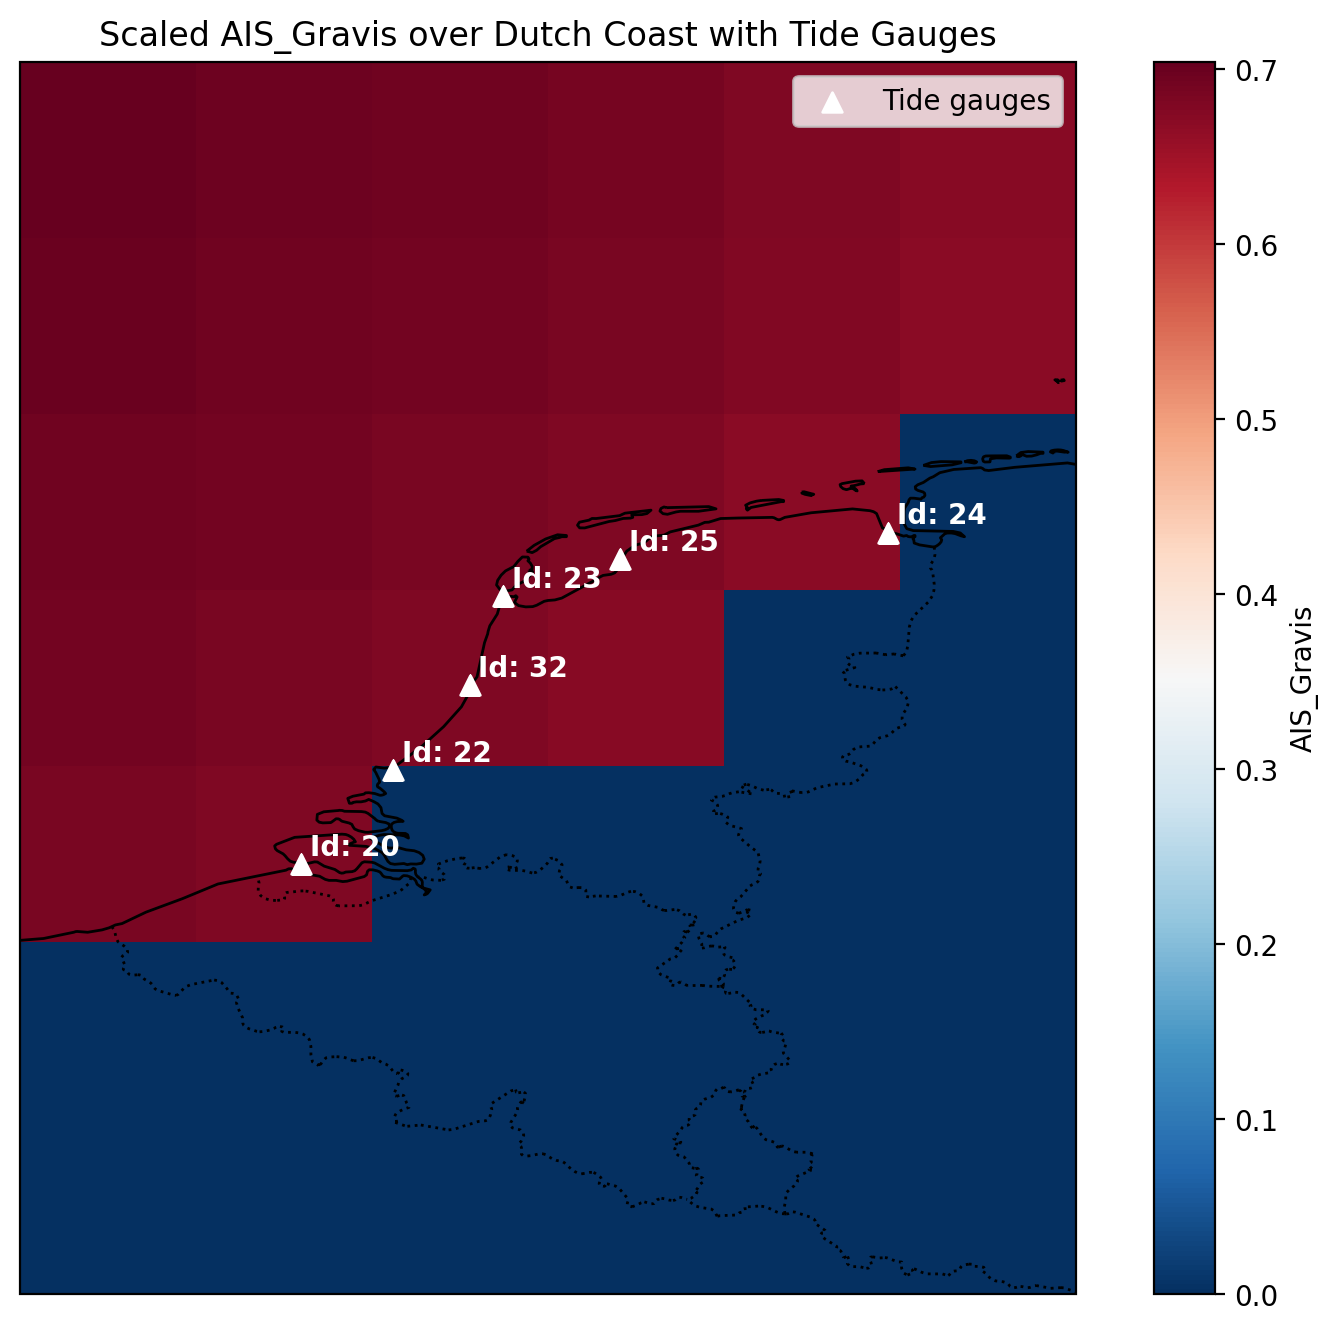

In [30]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

tg_id = [20, 22, 23, 24, 25, 32]
#Extract latitude and longitude from a tide gauge station from the list. 
tg_coord = slc.tg_lat_lon(tg_id[0])
#print(tg_coord)



# Extract coordinates
tg_coords = [slc.tg_lat_lon(tg) for tg in tg_id]
tg_lats = [c[0] for c in tg_coords]
tg_lons = [c[1] for c in tg_coords]


# Define region (Dutch coast)
lon_min, lon_max = 2,8 #3, 7
lat_min, lat_max = 49, 56 #51, 54

# Select region
da_region = Gravis_ant_ds['AIS_Gravis'].sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_min, lat_max)
)

# Pick a specific time if dataset has time dimension
if 'time' in da_region.dims:
    da_region = da_region.isel(time=-1)-da_region.isel(time=0)  # Last time step minus first timestep

# Plot
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot GRAVIS data
im = da_region.plot(ax=ax, cmap='RdBu_r', add_colorbar=True)

# Add coastlines and borders
ax.coastlines(resolution='10m', zorder = 1 )
ax.add_feature(cfeature.BORDERS, linestyle=':')

# Plot tide gauge stations
ax.scatter(tg_lons, tg_lats, color='white', s=50, marker='^', label='Tide gauges', zorder=10)

# Add tide gauge IDs as labels
for lon, lat, tg in zip(tg_lons, tg_lats, tg_id):
    ax.text(lon + 0.05, lat + 0.05, 'Id: ' + str(tg), color='white', fontsize=10, weight='bold', zorder=10)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.set_title('Scaled AIS_Gravis over Dutch Coast with Tide Gauges')
ax.legend()

plt.show()


Since station 22 does not overlap with sea for this landsea mask, the sea level rise at the location of this station will set to zero. For now, the value of station 32 is used there for computing the mean.  

In [9]:
## load file with rise antarctica to calculate the fraction: 
tg_id = [20, 32, 23, 24, 25, 32] #tg stations to calculate the mean @dutch coast #use 23 in stead of 22 for now 
#tg_coord = slc.tg_lat_lon(tg_id[0])



all_GRAVANT = []


for tg in tg_id: 
    tg_coord = slc.tg_lat_lon(tg)

    sel_da = Gravis_ant_ds['AIS_Gravis'].ffill('lon', 3).bfill('lon', 3)

    loc_da = sel_da.sel(lat = tg_coord[0], 
                    lon = tg_coord[1], 
                    method = 'nearest')

    fr_name = {
        'tws' : 'TWS', 
        'AIS' : 'Antarctica', 
        'GrIS' : 'Greenland', 
        'glac' : 'Glaciers',
        'grav': 'Ant_gravis',
        'grav2': 'Gre_gravis'}
 
    GRAVANT = loc_da.squeeze().reset_coords(drop=True).to_dataframe(name=fr_name['grav'])  
    #print(f'tgid{tg}')
    #display(GRAVANT)
    all_GRAVANT.append(GRAVANT)
    #all_GRAVGRE.append(GRAVGRE)


# Helper function to compute mean across tide gauges
def mean_across_gauges(list_of_series):
    return pd.concat(list_of_series, axis=1).mean(axis=1)

# Compute mean time series for each contribution

mean_GRAVANT = mean_across_gauges(all_GRAVANT)


# Combine all mean series into a single dataframe
mean_df = pd.DataFrame({
    #'Antarctica_mean': mean_ANT,
   # 'Greenland_mean': mean_GRE,
    'Ant_gravis_mean': mean_GRAVANT
   # 'Gre_gravis_mean': mean_GRAVGRE
})


# Ensure the index is numeric or datetime
mean_df.index = pd.to_numeric(mean_df.index, errors='coerce')

#display(all_GRAVANT)
display(mean_df)

,Ant_gravis_mean
time,
2002,0.000000
2003,0.029379
2004,0.060169
2005,0.070771
2006,0.058734
2007,0.102009
2008,0.184707
2009,0.169667
2010,0.220395


In [46]:
dutch_coast = mean_df['Ant_gravis_mean'] 
#display(dutch_coast)
mean_world = Gravis_ant_ds['Meanslr']
#display(mean_world) 
fraction = dutch_coast/mean_world
#display(fraction)

# Combine the three values into one DataFrame
combined = pd.DataFrame({
    'Dutch coast': dutch_coast, 
    'Mean': mean_world,
    'Fraction (Dutch/global mean )': fraction
})

display(combined)
dutch1 = dutch_coast.loc[2007] - dutch_coast.loc[2002] 
world1 = mean_world.loc[2007] - mean_world.loc[2002] 
frac1 = dutch1/world1
print(frac1.values) 

dutch2 = dutch_coast.loc[2014] - dutch_coast.loc[2009] 
world2 = mean_world.loc[2014] - mean_world.loc[2009] 
frac2 = dutch2/world2
print(frac2.values) 

dutch3 = dutch_coast.loc[2017] - dutch_coast.loc[2012] 
world3 = mean_world.loc[2017] - mean_world.loc[2012] 
frac3 = dutch3/world3
print(frac3.values)

dutch4 = dutch_coast.loc[2024] - dutch_coast.loc[2019] 
world4 = mean_world.loc[2024] - mean_world.loc[2019] 
frac4 = dutch4/world4
print(frac4.values)


,Dutch coast,Mean,Fraction (Dutch/global mean )
time,,,
2002,0.000000,0.000000,NaN
2003,0.029379,0.026242,1.119543
2004,0.060169,0.056963,1.056290
2005,0.070771,0.068128,1.038785
2006,0.058734,0.057955,1.013439
2007,0.102009,0.099399,1.026251
2008,0.184707,0.178319,1.035822
2009,0.169667,0.174611,0.971681
2010,0.220395,0.227812,0.967444


1.0262512171172553
0.9703456960313929
1.0288169985976376
0.6906877887052537


(97, 117)


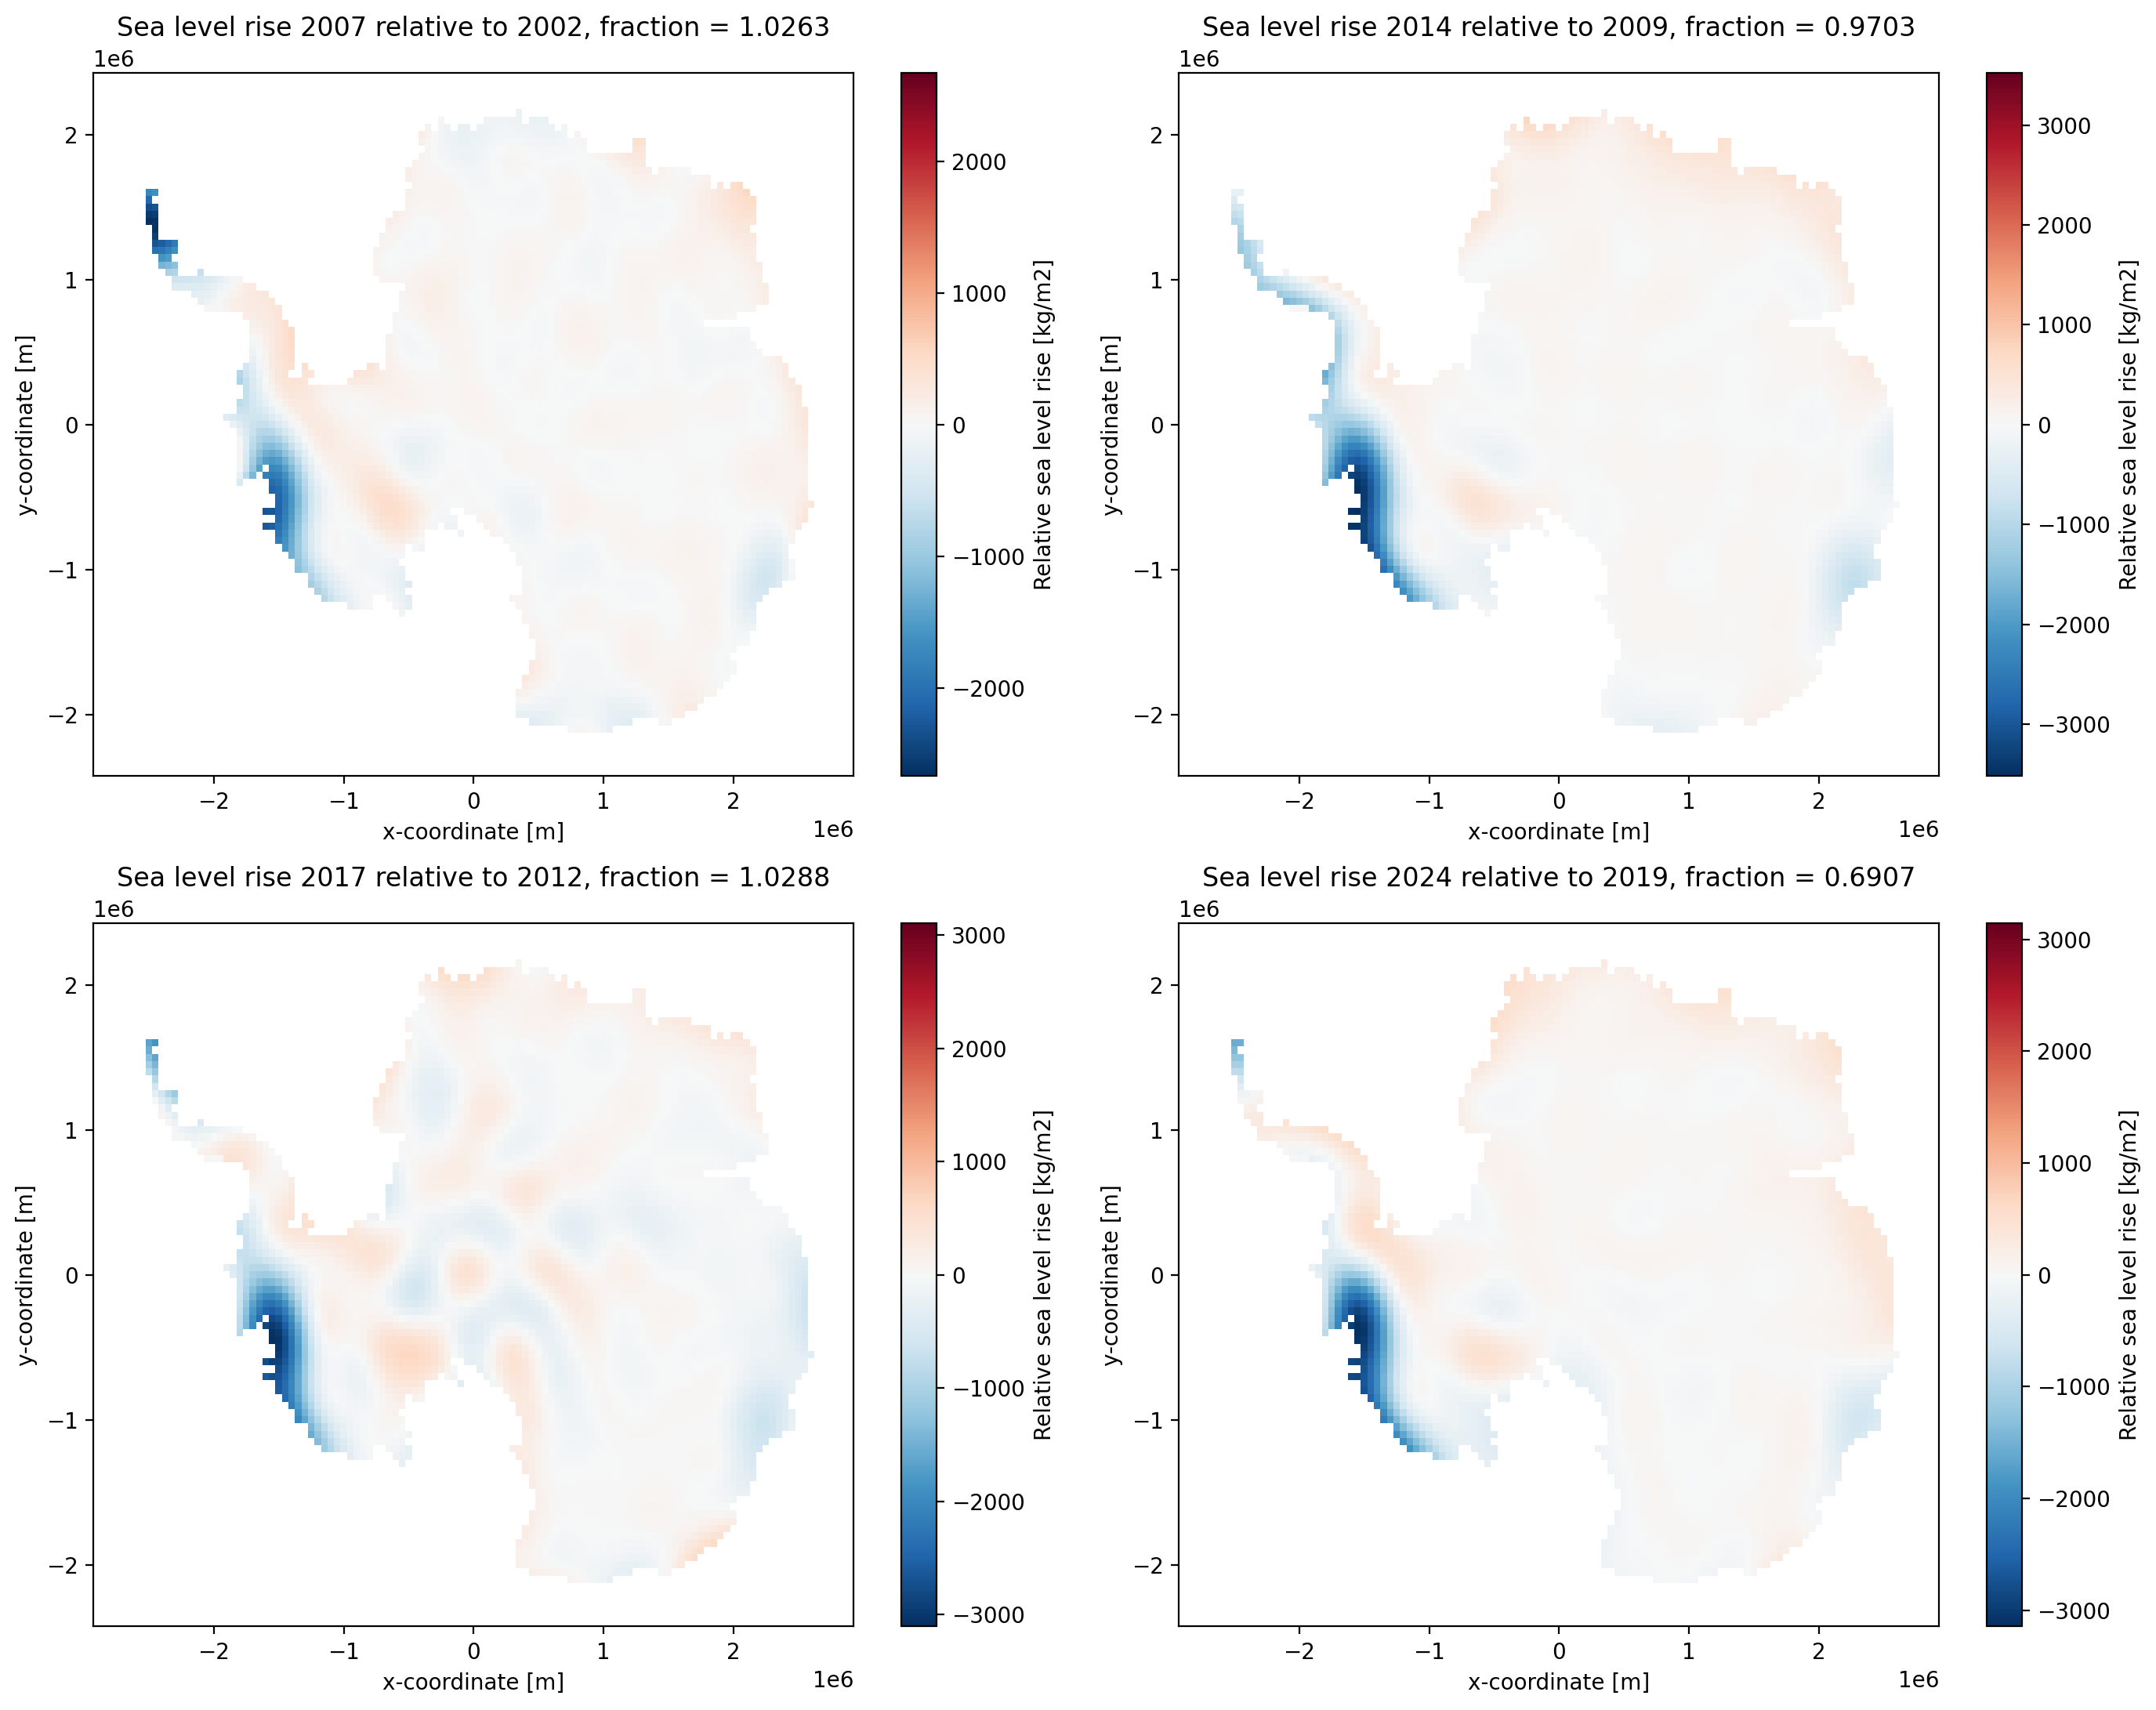

['2002-12-31T00:00:00.000000000' '2003-12-31T00:00:00.000000000'
 '2004-12-31T00:00:00.000000000' '2005-12-31T00:00:00.000000000'
 '2006-12-31T00:00:00.000000000' '2007-12-31T00:00:00.000000000'
 '2008-12-31T00:00:00.000000000' '2009-12-31T00:00:00.000000000'
 '2010-12-31T00:00:00.000000000' '2011-12-31T00:00:00.000000000'
 '2012-12-31T00:00:00.000000000' '2013-12-31T00:00:00.000000000'
 '2014-12-31T00:00:00.000000000' '2015-12-31T00:00:00.000000000'
 '2016-12-31T00:00:00.000000000' '2017-12-31T00:00:00.000000000'
 '2018-12-31T00:00:00.000000000' '2019-12-31T00:00:00.000000000'
 '2020-12-31T00:00:00.000000000' '2021-12-31T00:00:00.000000000'
 '2022-12-31T00:00:00.000000000' '2023-12-31T00:00:00.000000000'
 '2024-12-31T00:00:00.000000000']


In [55]:
#Plotjes maken: 
print(ant_y['dm'].sel(time='2002').squeeze().shape)

diff1 = ant_y['dm'].sel(time='2007').squeeze() - ant_y['dm'].sel(time='2002').squeeze()  # squeeze removes the time dimension (without dimension is (1,x,y) and now (x,y), with isel it is removed automatically. 
diff2 = ant_y['dm'].sel(time='2014').squeeze() - ant_y['dm'].sel(time='2009').squeeze()
diff3 = ant_y['dm'].sel(time='2017').squeeze() - ant_y['dm'].sel(time='2012').squeeze() 
diff4 = ant_y['dm'].sel(time='2024').squeeze() - ant_y['dm'].sel(time='2019').squeeze()


# plot the two difference figures
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 11))

# Plot the differences
diff1.plot(ax=ax1, cmap='RdBu_r', add_colorbar=True, cbar_kwargs={'label':'Relative sea level rise [kg/m2]'})
diff2.plot(ax=ax2, cmap='RdBu_r', add_colorbar=True, cbar_kwargs={'label':'Relative sea level rise [kg/m2]'})
diff3.plot(ax=ax3, cmap='RdBu_r', add_colorbar=True, cbar_kwargs={'label':'Relative sea level rise [kg/m2]'})
diff4.plot(ax=ax4, cmap='RdBu_r', add_colorbar=True, cbar_kwargs={'label':'Relative sea level rise [kg/m2]'})

# Add titles with fraction values
ax1.set_title(f'Sea level rise 2007 relative to 2002, fraction = {frac1.values:.4f}')
ax2.set_title(f'Sea level rise 2014 relative to 2009, fraction = {frac2.values:.4f}')
ax3.set_title(f'Sea level rise 2017 relative to 2012, fraction = {frac3.values:.4f}')
ax4.set_title(f'Sea level rise 2024 relative to 2019, fraction = {frac4.values:.4f}')


plt.tight_layout()
plt.show()

print(ant_y['time'].values)